# AI Nutrition Coach
**Course:** Artificial Intelligence  
**Team Members:** Amna Dilshad & Fiza Mubbsher

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

## 1. Data Description

In [2]:
df = pd.read_csv("nutrition_coach_dataset.csv")

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (91, 11)

Column Names:
 ['food_name', 'category', 'calories', 'protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'sugar_g', 'sodium_mg', 'calcium_mg', 'iron_mg']

Data Types:
 food_name         str
category          str
calories        int64
protein_g     float64
carbs_g       float64
fat_g         float64
fiber_g       float64
sugar_g       float64
sodium_mg       int64
calcium_mg      int64
iron_mg       float64
dtype: object

First 5 rows:


,food_name,category,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,calcium_mg,iron_mg
0,green tea,Beverages,1,0.2,0.0,0.0,0.0,0.0,1,0,0.02
1,orange juice,Beverages,45,0.7,10.4,0.2,0.2,8.4,1,11,0.20
2,butter,Dairy,717,0.9,0.1,81.1,0.0,0.1,576,24,0.02
3,cheddar cheese,Dairy,403,25.0,1.3,33.1,0.0,0.5,621,710,0.68
4,cottage cheese,Dairy,98,11.1,3.4,4.3,0.0,2.7,364,83,0.15


In [3]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,calcium_mg,iron_mg
count,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,227.417582,10.186813,17.731868,13.385714,2.846154,4.957143,164.659341,76.428571,1.692967
std,199.376086,10.778798,18.112463,20.690441,5.116755,7.488987,213.315323,118.102135,1.997824
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,68.500000,2.200000,3.600000,0.400000,0.000000,0.550000,4.500000,14.000000,0.275000
50%,160.000000,7.500000,12.000000,4.300000,1.700000,2.600000,55.000000,40.000000,1.200000
75%,320.000000,15.950000,26.250000,16.050000,2.800000,5.300000,310.000000,94.000000,2.205000
max,884.000000,75.000000,84.000000,100.000000,34.400000,52.000000,730.000000,710.000000,11.900000


In [4]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


food_name     0
category      0
calories      0
protein_g     0
carbs_g       0
fat_g         0
fiber_g       0
sugar_g       0
sodium_mg     0
calcium_mg    0
iron_mg       0
dtype: int64

## 2. Data Preprocessing

In [5]:
# duplicates checking
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Duplicate rows: 0
After removing duplicates: (91, 11)


In [6]:
# fill any missing numeric values with column median
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print("Missing values after fix:", df.isnull().sum().sum())

Missing values after fix: 0


In [7]:
# clean food_name text to lowercase so like all these would be same: banana,BANANA,Banana
df["food_name"] = df["food_name"].str.lower().str.strip()
print("Sample cleaned names:", df["food_name"].head())

Sample cleaned names: 0         green tea
1      orange juice
2            butter
3    cheddar cheese
4    cottage cheese
Name: food_name, dtype: str


In [8]:
# label encode the category column, it converts food categories(like Dairy, Fruit, Meat) into numbers
le = LabelEncoder()
df["category_encoded"] = le.fit_transform(df["category"])
print("Category encoding:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Category encoding:
{'Beverages': np.int64(0), 'Dairy': np.int64(1), 'Eggs': np.int64(2), 'Fats & Oils': np.int64(3), 'Fruits': np.int64(4), 'Grains & Cereals': np.int64(5), 'Legumes': np.int64(6), 'Meat & Poultry': np.int64(7), 'Mixed Dishes / Meals': np.int64(8), 'Nuts & Seeds': np.int64(9), 'Seafood': np.int64(10), 'Snacks': np.int64(11), 'Supplements': np.int64(12), 'Vegetables': np.int64(13)}


In [9]:
# min-max normalize all numeric nutrient columns
# calories might be= 2000, protein might be: 50, iron might be: 18
# so we scale all nutrition values between 0 and 1 so it makes different nutrients comparable and helps model work better
scaler = MinMaxScaler()
nutrient_cols = ["calories","protein_g","carbs_g","fat_g",
                 "fiber_g","sugar_g","sodium_mg","calcium_mg","iron_mg"]
df_scaled = df.copy()
df_scaled[nutrient_cols] = scaler.fit_transform(df[nutrient_cols])
print("Normalized data sample:")
df_scaled[nutrient_cols].head()

Normalized data sample:


,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,calcium_mg,iron_mg
0,0.000000,0.002667,0.000000,0.000,0.000000,0.000000,0.001370,0.000000,0.001681
1,0.049830,0.009333,0.123810,0.002,0.005814,0.161538,0.001370,0.015493,0.016807
2,0.810872,0.012000,0.001190,0.811,0.000000,0.001923,0.789041,0.033803,0.001681
3,0.455266,0.333333,0.015476,0.331,0.000000,0.009615,0.850685,1.000000,0.057143
4,0.109853,0.148000,0.040476,0.043,0.000000,0.051923,0.498630,0.116901,0.012605


In [10]:
# save preprocessed dataset
df.to_csv("nutrition_clean.csv", index=False)
print("Preprocessed dataset saved as nutrition_clean.csv")

Preprocessed dataset saved as nutrition_clean.csv


## 3. Data Visualization

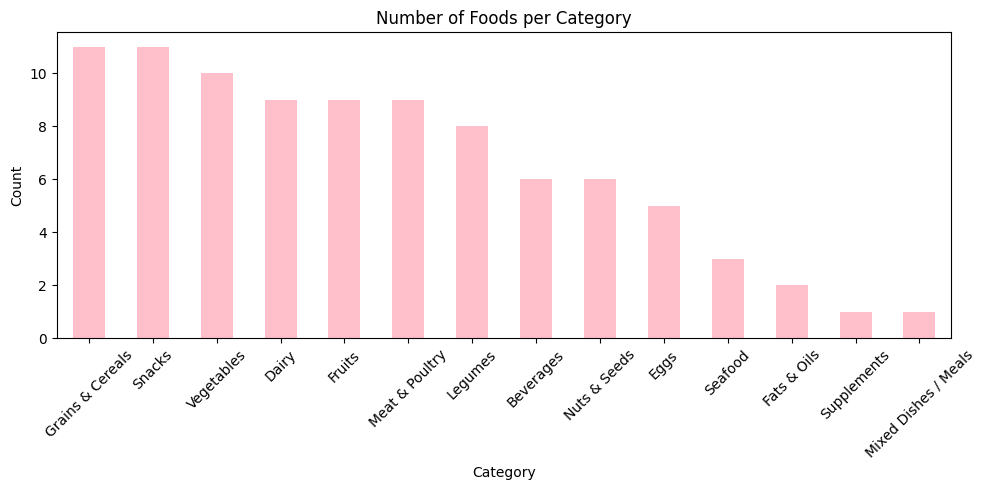

In [11]:
# graph 1 - how many foods per category
plt.figure(figsize=(10,5))
df["category"].value_counts().plot(kind="bar", color="pink")
plt.title("Number of Foods per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

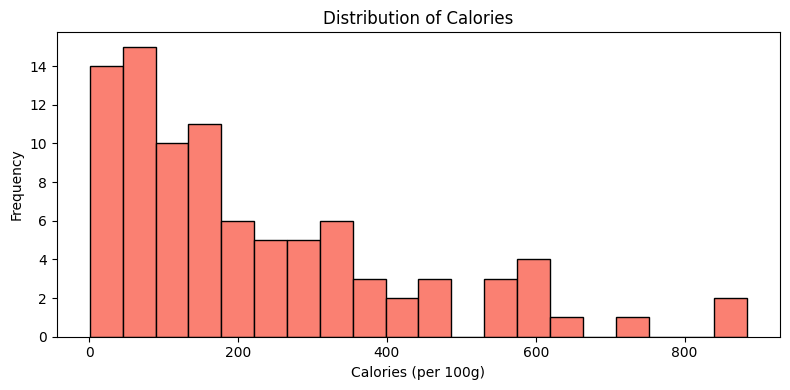

In [12]:
# graph 2 - calorie distribution
plt.figure(figsize=(8,4))
plt.hist(df["calories"], bins=20, color="salmon", edgecolor="black")
plt.title("Distribution of Calories")
plt.xlabel("Calories (per 100g)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

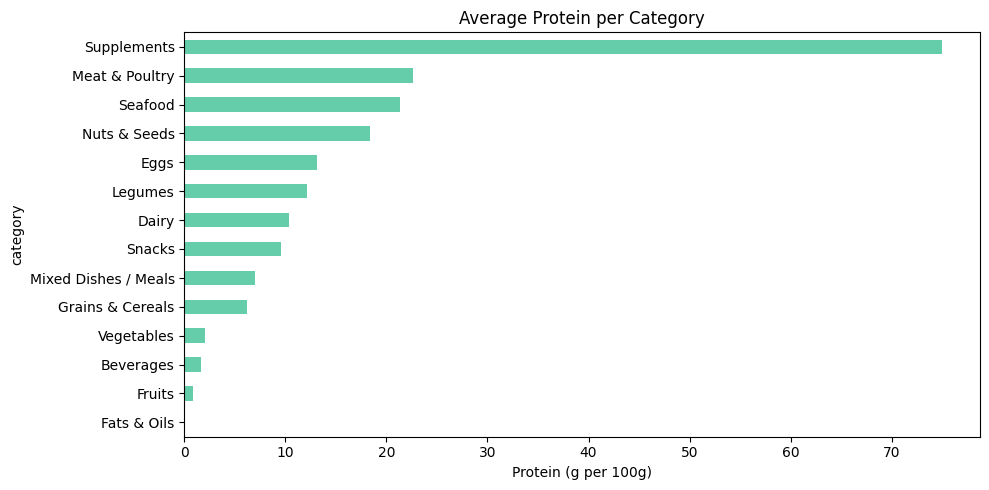

In [13]:
# graph 3 - average protein per category
plt.figure(figsize=(10,5))
df.groupby("category")["protein_g"].mean().sort_values().plot(kind="barh", color="mediumaquamarine")
plt.title("Average Protein per Category")
plt.xlabel("Protein (g per 100g)")
plt.tight_layout()
plt.show()

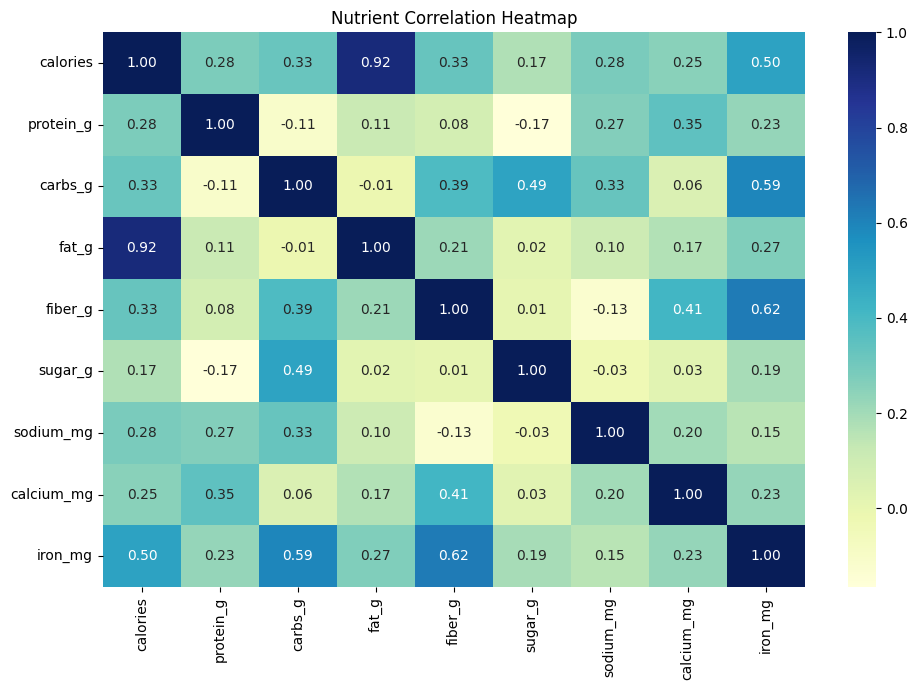

In [14]:
# graph 4 - correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df[nutrient_cols].corr(), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Nutrient Correlation Heatmap")
plt.tight_layout()
plt.show()

C:\Users\T470\AppData\Local\Temp\ipykernel_1632\2045753401.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="fat_g", palette="Set2")


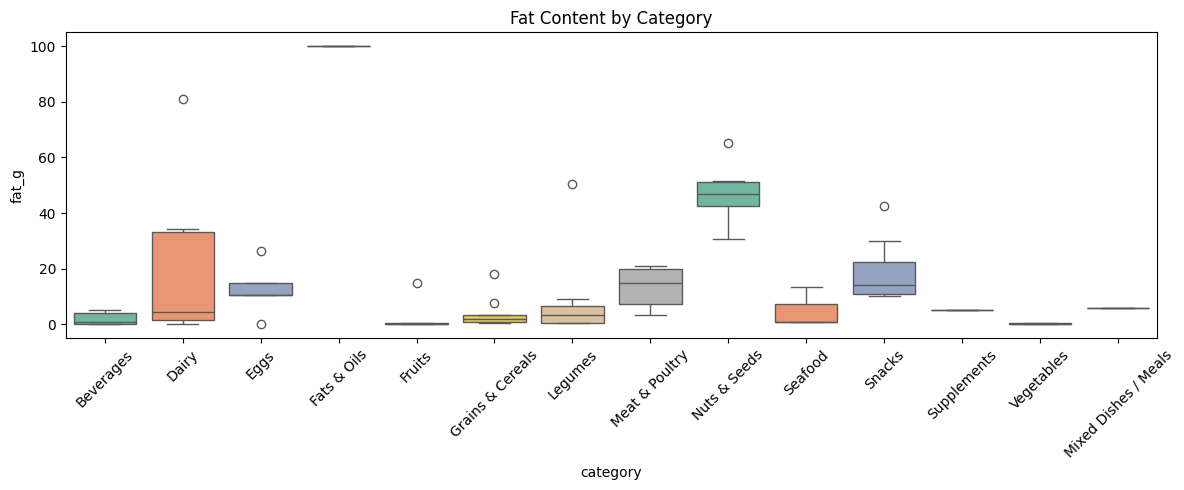

In [15]:
# graph 5 - boxplot of fat by category
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x="category", y="fat_g", palette="Set2")
plt.title("Fat Content by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

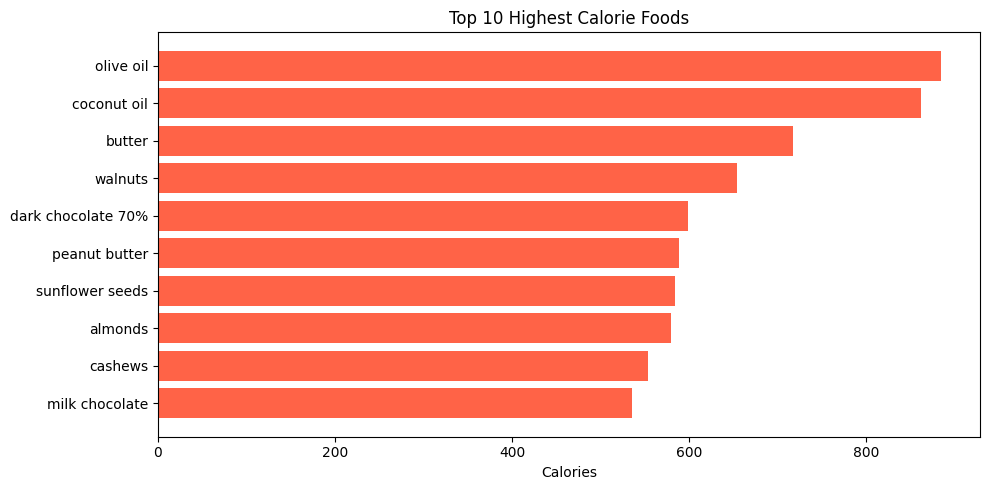

In [16]:
# graph 6 - top 10 highest calorie foods
plt.figure(figsize=(10,5))
top10 = df.nlargest(10, "calories")[["food_name","calories"]]
plt.barh(top10["food_name"], top10["calories"], color="tomato")
plt.title("Top 10 Highest Calorie Foods")
plt.xlabel("Calories")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Nutrition Lookup System

In [17]:
def get_nutrition(food_name):
    food_name = food_name.lower().strip()
    result = df[df["food_name"] == food_name]
    
    if result.empty:
        result = df[df["food_name"].str.contains(food_name, na=False)]
    
    if result.empty:
        print(f"Sorry, '{food_name}' not found in database.")
        return None
    
    row = result.iloc[0]
    print(f"\nNutrition Info for: {row['food_name'].upper()}")
    print(f"  Category   : {row['category']}")
    print(f"  Calories   : {row['calories']} kcal")
    print(f"  Protein    : {row['protein_g']} g")
    print(f"  Carbs      : {row['carbs_g']} g")
    print(f"  Fat        : {row['fat_g']} g")
    print(f"  Fiber      : {row['fiber_g']} g")
    print(f"  Sugar      : {row['sugar_g']} g")
    print(f"  Sodium     : {row['sodium_mg']} mg")
    print(f"  Calcium    : {row['calcium_mg']} mg")
    print(f"  Iron       : {row['iron_mg']} mg")
    return row

get_nutrition("banana")


Nutrition Info for: BANANA
  Category   : Fruits
  Calories   : 89 kcal
  Protein    : 1.1 g
  Carbs      : 23.0 g
  Fat        : 0.3 g
  Fiber      : 2.6 g
  Sugar      : 12.2 g
  Sodium     : 1 mg
  Calcium    : 5 mg
  Iron       : 0.26 mg


food_name           banana
category            Fruits
calories                89
protein_g              1.1
carbs_g               23.0
fat_g                  0.3
fiber_g                2.6
sugar_g               12.2
sodium_mg                1
calcium_mg               5
iron_mg               0.26
category_encoded         4
Name: 18, dtype: object

In [18]:
get_nutrition("chicken breast")
get_nutrition("oatmeal cooked")


Nutrition Info for: CHICKEN BREAST
  Category   : Meat & Poultry
  Calories   : 165 kcal
  Protein    : 31.0 g
  Carbs      : 0.0 g
  Fat        : 3.6 g
  Fiber      : 0.0 g
  Sugar      : 0.0 g
  Sodium     : 74 mg
  Calcium    : 15 mg
  Iron       : 1.04 mg

Nutrition Info for: OATMEAL COOKED
  Category   : Grains & Cereals
  Calories   : 68 kcal
  Protein    : 2.4 g
  Carbs      : 12.0 g
  Fat        : 1.4 g
  Fiber      : 1.7 g
  Sugar      : 0.3 g
  Sodium     : 49 mg
  Calcium    : 11 mg
  Iron       : 0.7 mg


food_name             oatmeal cooked
category            Grains & Cereals
calories                          68
protein_g                        2.4
carbs_g                         12.0
fat_g                            1.4
fiber_g                          1.7
sugar_g                          0.3
sodium_mg                         49
calcium_mg                        11
iron_mg                          0.7
category_encoded                   5
Name: 27, dtype: object

## 5. Calorie Level Classifier (Rule-Based)

In [19]:
def classify_calorie_level(calories):
    if calories < 100:
        return "Low"
    elif calories <= 300:
        return "Medium"
    else:
        return "High"

df["calorie_level"] = df["calories"].apply(classify_calorie_level)

print("Calorie level distribution:")
print(df["calorie_level"].value_counts())

Calorie level distribution:
calorie_level
Medium    36
Low       30
High      25
Name: count, dtype: int64


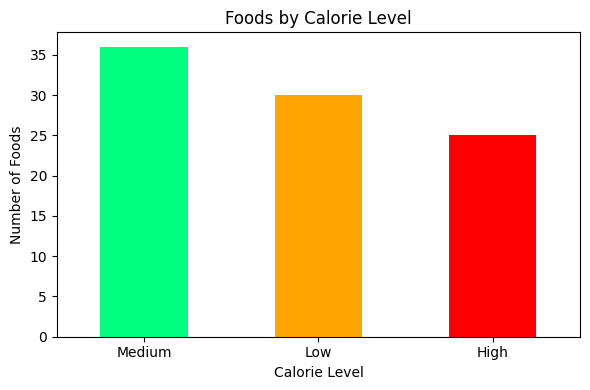

In [20]:
plt.figure(figsize=(6,4))
df["calorie_level"].value_counts().plot(kind="bar", color=["springgreen","orange","red"])
plt.title("Foods by Calorie Level")
plt.xlabel("Calorie Level")
plt.ylabel("Number of Foods")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
def predict_calorie_level(food_name):
    row = get_nutrition(food_name)
    if row is not None:
        level = classify_calorie_level(row["calories"])
        print(f"\nCalorie Level: {level}")
        if level == "Low":
            print("This is a low calorie food. Great for weight loss goals!")
        elif level == "Medium":
            print("This is a moderate calorie food. Good for balanced diet.")
        else:
            print("This is a high calorie food. Eat in moderation.")

predict_calorie_level("avocado")
predict_calorie_level("spinach")
predict_calorie_level("peanut butter")


Nutrition Info for: AVOCADO
  Category   : Fruits
  Calories   : 160 kcal
  Protein    : 2.0 g
  Carbs      : 8.5 g
  Fat        : 14.7 g
  Fiber      : 6.7 g
  Sugar      : 0.7 g
  Sodium     : 7 mg
  Calcium    : 12 mg
  Iron       : 0.55 mg

Calorie Level: Medium
This is a moderate calorie food. Good for balanced diet.

Nutrition Info for: SPINACH
  Category   : Vegetables
  Calories   : 23 kcal
  Protein    : 2.9 g
  Carbs      : 3.6 g
  Fat        : 0.4 g
  Fiber      : 2.2 g
  Sugar      : 0.4 g
  Sodium     : 79 mg
  Calcium    : 99 mg
  Iron       : 2.71 mg

Calorie Level: Low
This is a low calorie food. Great for weight loss goals!

Nutrition Info for: PEANUT BUTTER
  Category   : Legumes
  Calories   : 588 kcal
  Protein    : 25.1 g
  Carbs      : 20.1 g
  Fat        : 50.4 g
  Fiber      : 6.0 g
  Sugar      : 9.2 g
  Sodium     : 459 mg
  Calcium    : 49 mg
  Iron       : 1.74 mg

Calorie Level: High
This is a high calorie food. Eat in moderation.


## 6. Daily Meal Logger & Nutritional Gap Analysis

In [22]:
RDA = {
    "calories"   : 2000,
    "protein_g"  : 50,
    "carbs_g"    : 275,
    "fat_g"      : 78,
    "fiber_g"    : 28,
    "sugar_g"    : 50,
    "sodium_mg"  : 2300,
    "calcium_mg" : 1000,
    "iron_mg"    : 18
}

def log_meal(food_list):
    print("------------- DAILY MEAL LOG -------------")
    
    totals = {key: 0 for key in RDA}
    found_foods = []
    
    for food in food_list:
        food = food.lower().strip()
        result = df[df["food_name"] == food]
        if result.empty:
            result = df[df["food_name"].str.contains(food, na=False)]
        if result.empty:
            print(f"  WARNING: '{food}' not found, skipping.")
            continue
        row = result.iloc[0]
        found_foods.append(row["food_name"])
        for key in totals:
            totals[key] += row[key]
    
    print(f"\nFoods logged: {found_foods}")
    print("\nNutritional Totals vs Recommended Daily Intake")
    print(f"{'Nutrient':<15} {'Your Intake':>12} {'RDA':>8} {'Status':>12}")
    print("-" * 50)
    
    feedback = []
    for key, rda_val in RDA.items():
        intake = round(totals[key], 1)
        percent = (intake / rda_val) * 100
        if percent < 70:
            status = "LOW"
            feedback.append(f"Your {key} is LOW ({percent:.0f}% of RDA). Eat more {key}-rich foods.")
        elif percent > 130:
            status = "EXCESS"
            feedback.append(f"Your {key} is EXCESS ({percent:.0f}% of RDA). Try to reduce.")
        else:
            status = "OK"
        print(f"{key:<15} {intake:>12} {rda_val:>8} {status:>12}")
    
    print("\n--- Personalized Feedback ---")
    if not feedback:
        print("GREAT JOB! Your nutrition looks balanced today")
    else:
        for f in feedback:
            print(f"  * {f}")
    
    return totals

daily_totals = log_meal([
    "egg whole",
    "oatmeal cooked",
    "banana",
    "chicken breast",
    "brown rice cooked",
    "broccoli",
    "greek yogurt"
])

------------- DAILY MEAL LOG -------------

Foods logged: ['egg whole', 'oatmeal cooked', 'banana', 'chicken breast', 'brown rice cooked', 'broccoli', 'greek yogurt']

Nutritional Totals vs Recommended Daily Intake
Nutrient         Your Intake      RDA       Status
--------------------------------------------------
calories                 682     2000          LOW
protein_g               63.1       50           OK
carbs_g                 69.8      275          LOW
fat_g                   17.6       78          LOW
fiber_g                  8.7       28          LOW
sugar_g                 18.9       50          LOW
sodium_mg                322     2300          LOW
calcium_mg               255     1000          LOW
iron_mg                  5.1       18          LOW

--- Personalized Feedback ---
  * Your calories is LOW (34% of RDA). Eat more calories-rich foods.
  * Your carbs_g is LOW (25% of RDA). Eat more carbs_g-rich foods.
  * Your fat_g is LOW (23% of RDA). Eat more fat_g-rich f

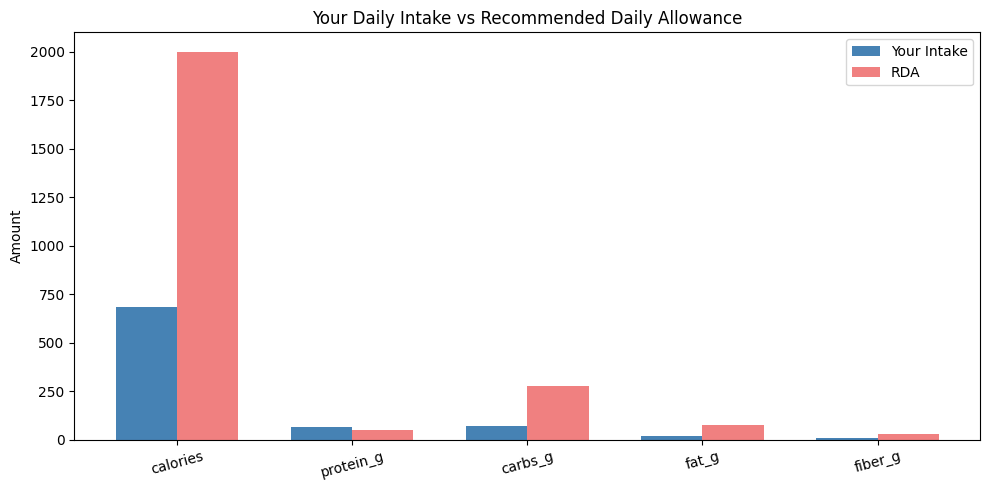

In [23]:
# visualize daily intake vs RDA as a bar chart
nutrients_to_plot = ["calories", "protein_g", "carbs_g", "fat_g", "fiber_g"]
intake_vals = [daily_totals[n] for n in nutrients_to_plot]
rda_vals    = [RDA[n] for n in nutrients_to_plot]

x = range(len(nutrients_to_plot))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar([i - width/2 for i in x], intake_vals, width, label="Your Intake", color="steelblue")
plt.bar([i + width/2 for i in x], rda_vals,    width, label="RDA",         color="lightcoral")
plt.xticks(list(x), nutrients_to_plot, rotation=15)
plt.title("Your Daily Intake vs Recommended Daily Allowance")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, silhouette_score)
from sklearn.decomposition import PCA

df = pd.read_csv("nutrition_clean.csv")
print("Data loaded:", df.shape)

Data loaded: (91, 12)


## 7. Regression Model — Predicting Calories

In [25]:
# goal: predict calories from other nutrients
features = ["protein_g", "carbs_g", "fat_g", "fiber_g", "sugar_g", "sodium_mg"]
target   = "calories"

x = df[features]
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# model 1 - linear regression
lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

# model 2 - random forest regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

print("Regression Results\n")
print("Linear Regression:")
print(f"  MAE  : {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, lr_pred)):.2f}")
print(f"  R2   : {r2_score(y_test, lr_pred):.2f}")
print("\nRandom Forest Regressor:")
print(f"  MAE  : {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, rf_pred)):.2f}")
print(f"  R2   : {r2_score(y_test, rf_pred):.2f}")

Regression Results

Linear Regression:
  MAE  : 7.34
  RMSE : 9.90
  R2   : 1.00

Random Forest Regressor:
  MAE  : 41.57
  RMSE : 66.12
  R2   : 0.78


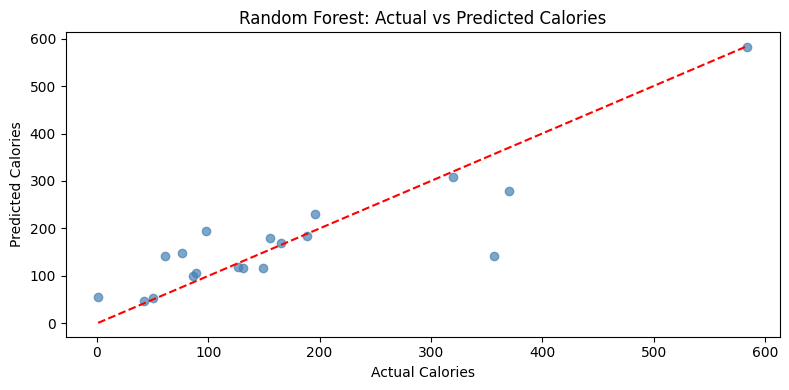

In [26]:
# visualize actual vs predicted calories
plt.figure(figsize=(8,4))
plt.scatter(y_test, rf_pred, color="steelblue", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Random Forest: Actual vs Predicted Calories")
plt.tight_layout()
plt.show()

## 8. Classification Model — Predicting Calorie Level

In [27]:
# create calorie level labels (same logic as Amna)
def classify_calorie_level(cal):
    if cal < 100:
        return "Low"
    elif cal <= 300:
        return "Medium"
    else:
        return "High"

df["calorie_level"] = df["calories"].apply(classify_calorie_level)

le = LabelEncoder()
df["calorie_level_encoded"] = le.fit_transform(df["calorie_level"])

features_clf = ["protein_g", "carbs_g", "fat_g", "fiber_g", "sugar_g", "sodium_mg", "calcium_mg", "iron_mg"]
x_clf = df[features_clf]
y_clf = df["calorie_level_encoded"]

x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_clf, y_clf, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train_c, y_train_c)
clf_pred = clf.predict(x_test_c)

print("Classification Results\n")
print(f"  Accuracy  : {accuracy_score(y_test_c, clf_pred):.2f}")
print(f"  Precision : {precision_score(y_test_c, clf_pred, average='weighted', zero_division=0):.2f}")
print(f"  Recall    : {recall_score(y_test_c, clf_pred, average='weighted', zero_division=0):.2f}")
print(f"  F1 Score  : {f1_score(y_test_c, clf_pred, average='weighted', zero_division=0):.2f}")

Classification Results

  Accuracy  : 0.79
  Precision : 0.87
  Recall    : 0.79
  F1 Score  : 0.79


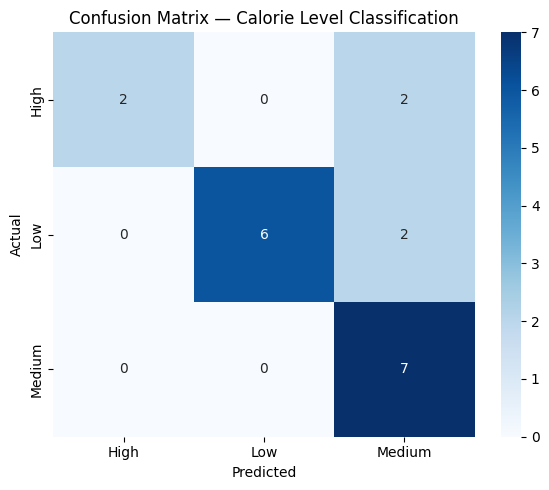

In [28]:
# confusion matrix heatmap
cm = confusion_matrix(y_test_c, clf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — Calorie Level Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 9. Clustering — Grouping Similar Foods

In [29]:
# normalize first
nutrient_cols = ["calories","protein_g","carbs_g","fat_g","fiber_g","sugar_g","sodium_mg","calcium_mg","iron_mg"]
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(df[nutrient_cols])

# kmeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(x_scaled)

sil_score = silhouette_score(x_scaled, df["cluster"])
print(f"Silhouette Score: {sil_score:.2f}")
print("(Score closer to 1.0 = better defined clusters)\n")
print("Foods per cluster:")
print(df["cluster"].value_counts())

Silhouette Score: 0.44
(Score closer to 1.0 = better defined clusters)

Foods per cluster:
cluster
0    56
1    24
3     7
2     4
Name: count, dtype: int64


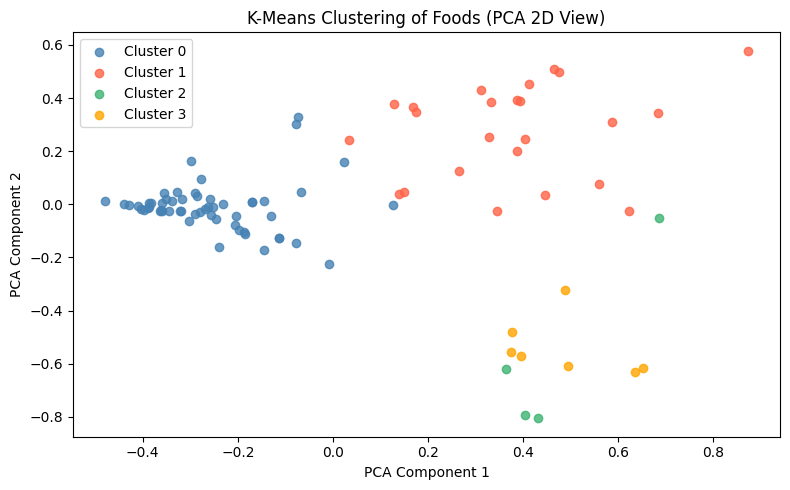

In [30]:
# visualize clusters using PCA to reduce to 2D
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8,5))
colors = ["steelblue","tomato","mediumseagreen","orange"]
for i in range(4):
    mask = df["cluster"] == i
    plt.scatter(x_pca[mask, 0], x_pca[mask, 1],
                label=f"Cluster {i}", color=colors[i], alpha=0.8)

plt.title("K-Means Clustering of Foods (PCA 2D View)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# see which foods are in each cluster
for i in range(4):
    foods = df[df["cluster"] == i]["food_name"].tolist()
    print(f"\nCluster {i} ({len(foods)} foods): {foods}")


Cluster 0 (56 foods): ['green tea', 'orange juice', 'cottage cheese', 'greek yogurt', 'low fat yogurt', 'skimmed milk', 'whole milk', 'egg white', 'egg whole', 'egg yolk', 'apple', 'avocado', 'banana', 'grapes', 'mango', 'orange', 'pineapple', 'strawberry', 'watermelon', 'brown rice cooked', 'oatmeal cooked', 'pasta cooked', 'quinoa cooked', 'white rice cooked', 'black beans cooked', 'chickpeas cooked', 'kidney beans cooked', 'lentils cooked', 'soybeans cooked', 'tofu firm', 'chicken breast', 'ground beef 80%', 'lamb chop', 'pork tenderloin', 'turkey breast', 'salmon fillet', 'shrimp', 'tuna canned', 'whey protein powder', 'bell pepper red', 'broccoli', 'carrot', 'cucumber', 'garlic', 'onion', 'potato', 'spinach', 'sweet potato', 'tomato', 'boiled egg', 'fried egg', 'chicken kabab', 'lassi', 'chai', 'cola', 'milkshake']

Cluster 1 (24 foods): ['cheddar cheese', 'cream cheese', 'mozzarella', 'corn flakes', 'white bread', 'whole wheat bread', 'peanut butter', 'protein bar', 'whole grain